In [24]:
# Load this data OMPLLD_croin_cassan_0.sample.csv
import pandas as pd
import numpy as np
# Load the data
data = pd.read_csv('repsample/OMPLLD_croin_cassan_0.sample.csv')
# Display the first few rows of the data
print(data.head())

   EventID  SubRun  Field  galactic_l  galactic_b      ra_deg    dec_deg  \
0      148      10      0    0.967270   -1.530864  268.473078 -28.892627   
1      549      10      0    1.000202   -1.450253  268.412753 -28.823413   
2      578      10      0    0.956517   -1.526617  268.462678 -28.899746   
3      589      10      0    0.984075   -1.525601  268.477607 -28.875476   
4      709      10      0    0.974666   -1.484763  268.431956 -28.862906   

   SourceID  Source_mul  Source_mub  ...  ObsGroup_1_flatlc  \
0     33118   -6.300858   -2.376964  ...                  0   
1     44428   -5.514805   -1.729932  ...                  0   
2     50095   -6.950542    0.916188  ...                  0   
3     45812   -9.849052    0.295055  ...                  0   
4     49920   -6.906426    0.055558  ...                  0   

   ObsGroup_1_flatchi2  ObsGroup_1_FiniteSourceflag  ObsGroup_1_chi2  \
0         1.520081e+05                            0       317.063424   
1         2.896727e+

In [25]:
# Load Natasha's data
ground_data = "../PopSyCLE/data/all_fields_Mrun_EWS_w_comp_params.fits"
#load the fits file
from astropy.io import fits
with fits.open(ground_data) as hdul:
    hdul.info()
    ground_data = hdul[1].data
    # Convert to numpy array and change byte order to native (little-endian)
    data_array = np.array(ground_data).byteswap().view(ground_data.dtype.newbyteorder('='))
    df_ground = pd.DataFrame(data_array)

df_ground.head()

print(df_ground["theta_E"])
print(data["thetaE"])

Filename: ../PopSyCLE/data/all_fields_Mrun_EWS_w_comp_params.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    342   5898R x 164C   [K, K, D, I, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, I, D, D, D, D, D, D, D, D, D, D, D, D, D, I, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, I, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 28A, 6A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
0       0.850656
1       0.513506
2       1.517226
3       1.171127
4       0.350934
          ...   
5893    0.503153
5894    0.171799
5895    0.225778
5896    0.501691
5897    0.166788
Name: theta_E, Length: 5898, dtype: float64
0       0.146919
1       0.152930


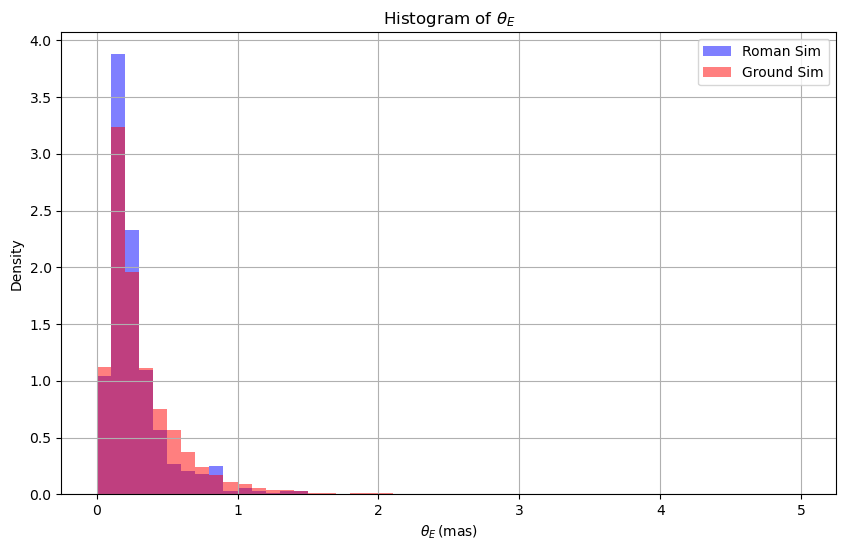

In [28]:
# histogram thetaE
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(data['thetaE'], bins=50, density=True, alpha=0.5, color='blue', range=(0, 5), weights=data['weight'])
plt.hist(df_ground["theta_E"], bins=50, density=True, alpha=0.5, color='red', range=(0, 5))
plt.legend(['Roman Sim', 'Ground Sim'])
plt.xlabel(r'$\theta_E\,(\rm{mas})$')
plt.ylabel('Density')
plt.title(r'Histogram of $\theta_E$')
plt.grid(True)
plt.show()